# Day 1 — Data Audit
**Real Estate Fraud Detection**

Goal: Load dataset, validate schema, analyze missingness, check price distribution, generate leakage report.

## 1. Working Directory Check

In [1]:
import os
print(os.getcwd())

C:\Users\mehal\Downloads\machinelearning\real_estate_fraud_detection\notebooks


## 2. Set Project Root (Run Once)

In [2]:
import os
from pathlib import Path

# Project root automatically find karo — chahe notebook kahin se bhi run ho
project_root = Path.cwd()
while not (project_root / 'configs').exists():
    project_root = project_root.parent
os.chdir(project_root)
print(f"Working directory: {os.getcwd()}")
# Expected: .../real_estate_fraud_detection  (NOT .../src, NOT .../notebooks)

Working directory: C:\Users\mehal\Downloads\machinelearning\real_estate_fraud_detection


## 3. Imports & Config

In [3]:
# FIX: sys.path mein project root add karo (not '..') 
# Cell 2 ke baad cwd = project_root, isliye '.' correct hai
import os, sys
sys.path.insert(0, os.path.abspath('.'))

import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path

from src.ingestion import (
    load_config, load_raw_data, validate_schema,
    assert_no_duplicates, analyze_missing,
    log_data_summary, check_price_distribution,
    generate_leakage_report
)

matplotlib.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# FIX: '../configs/config.yaml' → 'configs/config.yaml'
# Cell 2 ke baad cwd = project_root, '../' se upar chala jaata tha
CONFIG_PATH = 'configs/config.yaml'
cfg = load_config(CONFIG_PATH)
print(f"Project: {cfg['project']['name']} v{cfg['project']['version']}")

2026-05-11 10:45:58,794 - src.ingestion - INFO - Config loaded from configs\config.yaml — project: real_estate_fraud_detection v1.1.0


Project: real_estate_fraud_detection v1.1.0


## 4. Load Raw Data

In [4]:
# Load with schema enforcement + drop configured columns
df = load_raw_data(cfg)
print(f'Shape: {df.shape}')
df.head(3)

2026-05-11 10:45:58,815 - src.ingestion - INFO - Loading raw data from: data\raw\realtor-data.csv
2026-05-11 10:46:06,835 - src.ingestion - INFO - Raw shape: (2226382, 12)
2026-05-11 10:46:08,094 - src.ingestion - INFO - Dropped columns: ['street', 'brokered_by']
2026-05-11 10:46:08,096 - src.ingestion - INFO - Shape after drops: (2226382, 10)


Shape: (2226382, 10)


,status,price,bed,bath,acre_lot,city,state,zip_code,house_size,prev_sold_date
0,for_sale,105000.00,3.00,2.00,0.12,Adjuntas,Puerto Rico,601.00,920.00,NaN
1,for_sale,80000.00,4.00,2.00,0.08,Adjuntas,Puerto Rico,601.00,1527.00,NaN
2,for_sale,67000.00,2.00,1.00,0.15,Juana Diaz,Puerto Rico,795.00,748.00,NaN


## 5. Schema Validation

In [5]:
validate_schema(df, cfg)
print('✅ Schema validation passed')

# Dtype overview
dtype_df = pd.DataFrame({'dtype': df.dtypes, 'sample': df.iloc[0]}).reset_index()
dtype_df.columns = ['column', 'dtype', 'sample_value']
dtype_df

2026-05-11 10:46:08,150 - src.ingestion - INFO - Schema validation PASSED — 10 columns present


✅ Schema validation passed


,column,dtype,sample_value
0,status,object,for_sale
1,price,float64,105000.00
2,bed,float64,3.00
3,bath,float64,2.00
4,acre_lot,float64,0.12
5,city,object,Adjuntas
6,state,object,Puerto Rico
7,zip_code,object,601.00
8,house_size,float64,920.00
9,prev_sold_date,object,NaN


## 6. Duplicate Check

In [6]:
n_before = len(df)
df = assert_no_duplicates(df, cfg)
print(f'Rows before: {n_before:,} | After dedup: {len(df):,} | Removed: {n_before - len(df):,}')

2026-05-11 10:46:11,343 - src.ingestion - WARNING - Found 78726 duplicate rows (3.54%) — dropping
2026-05-11 10:46:15,580 - src.ingestion - INFO - Shape after dedup: (2147656, 10)


Rows before: 2,226,382 | After dedup: 2,147,656 | Removed: 78,726


## 7. Missing Value Analysis

2026-05-11 10:46:17,585 - src.ingestion - WARNING - HIGH NULL: 'prev_sold_date' has 31.7% missing
2026-05-11 10:46:17,588 - src.ingestion - INFO - Missing value analysis: 9/10 columns below 30.0% threshold


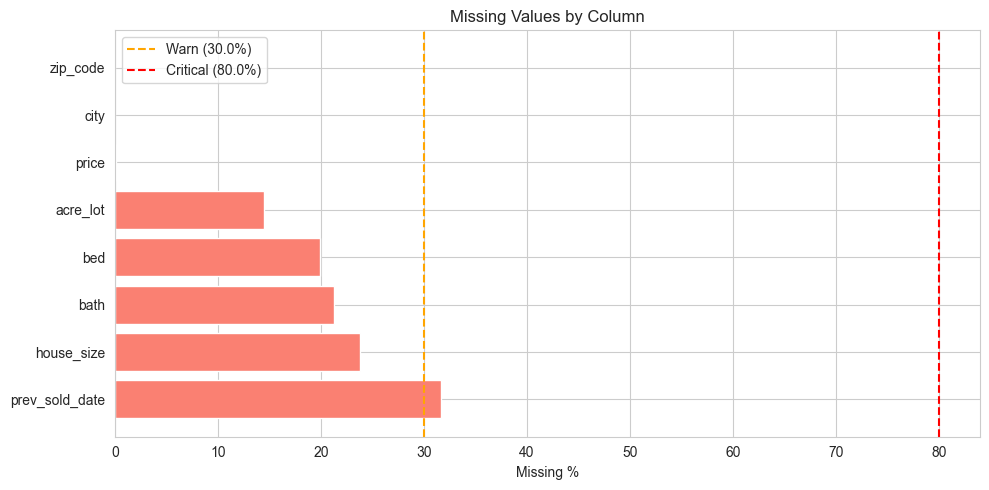

,column,null_count,null_pct,dtype
0,prev_sold_date,681113,31.71,object
1,house_size,511539,23.82,float64
2,bath,457363,21.30,float64
3,bed,427502,19.91,float64
4,acre_lot,310212,14.44,float64
5,price,1453,0.07,float64
6,city,1304,0.06,object
7,zip_code,297,0.01,object
8,status,0,0.00,object
9,state,8,0.00,object


In [7]:
missing_summary = analyze_missing(df, cfg)

# Visualise missingness
fig, ax = plt.subplots(figsize=(10, 5))
cols_with_nulls = missing_summary[missing_summary['null_pct'] > 0]
if len(cols_with_nulls) > 0:
    ax.barh(cols_with_nulls['column'], cols_with_nulls['null_pct'], color='salmon')
    ax.axvline(cfg['data_quality']['max_null_pct_warn'], color='orange', ls='--',
               label=f"Warn ({cfg['data_quality']['max_null_pct_warn']}%)")
    ax.axvline(cfg['data_quality']['max_null_pct_critical'], color='red', ls='--',
               label=f"Critical ({cfg['data_quality']['max_null_pct_critical']}%)")
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column')
    ax.legend()
    plt.tight_layout()
    # FIX: '../reports/plots' → 'reports/plots'
    Path('reports/plots').mkdir(parents=True, exist_ok=True)
    plt.savefig('reports/plots/missing_values.png', dpi=150)
    plt.show()
else:
    print('✅ No missing values found')

missing_summary

## 8. Numerical Feature Distributions (Raw vs Log)

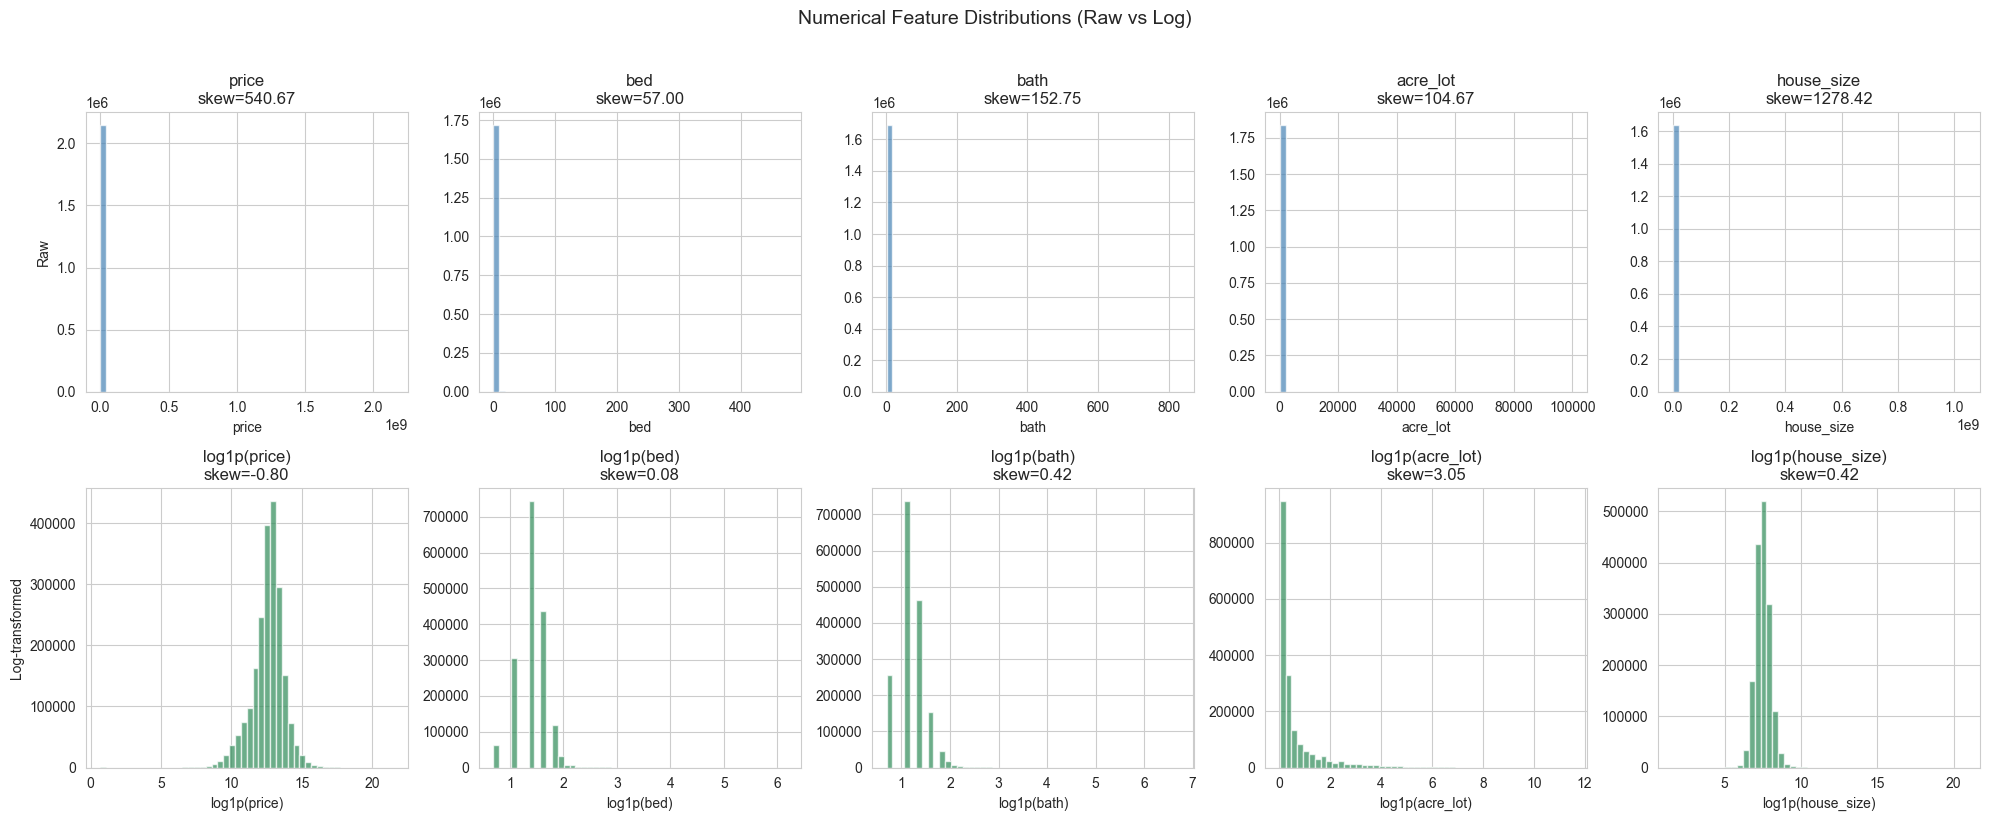

In [8]:
num_cols = [c for c in cfg['columns']['numerical'] if c in df.columns]

fig, axes = plt.subplots(2, len(num_cols), figsize=(4*len(num_cols), 8))
for i, col in enumerate(num_cols):
    data = df[col].dropna()
    # Raw distribution
    axes[0, i].hist(data, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    axes[0, i].set_title(f'{col}\nskew={data.skew():.2f}')
    axes[0, i].set_xlabel(col)
    # Log distribution
    log_data = np.log1p(data[data > 0])
    axes[1, i].hist(log_data, bins=50, color='seagreen', alpha=0.7, edgecolor='white')
    axes[1, i].set_title(f'log1p({col})\nskew={log_data.skew():.2f}')
    axes[1, i].set_xlabel(f'log1p({col})')

axes[0, 0].set_ylabel('Raw')
axes[1, 0].set_ylabel('Log-transformed')
plt.suptitle('Numerical Feature Distributions (Raw vs Log)', fontsize=14, y=1.02)
plt.tight_layout()
# FIX: '../reports/plots/...' → 'reports/plots/...'
plt.savefig('reports/plots/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Price Distribution Deep Dive

2026-05-11 10:46:31,499 - src.ingestion - INFO - Price distribution: mean=$534,901, median=$330,000, skew=540.672
2026-05-11 10:46:31,501 - src.ingestion - INFO -   → Log transform recommended (|skew|=540.672 > 1.0)


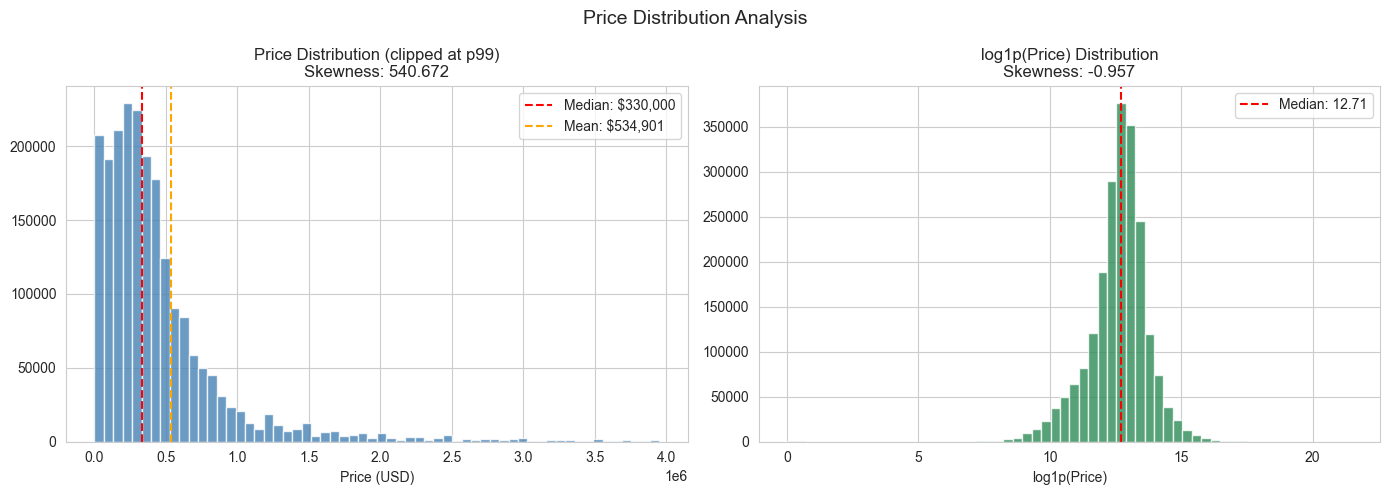


Price Stats:
  count: 2146203
  mean: 534900.58
  median: 330000.0
  std: 2172052.7
  min: 0.0
  max: 2147483600.0
  skewness: 540.672
  log_transform_recommended: True

Percentiles:
  p1: $12,000
  p5: $35,000
  p10: $69,500
  p25: $175,000
  p50: $330,000
  p75: $559,900
  p90: $950,000
  p95: $1,499,000
  p99: $3,950,000


In [9]:
price_info = check_price_distribution(df, cfg)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw price
price_data = df['price'].dropna()
p99 = np.percentile(price_data, 99)
axes[0].hist(price_data[price_data <= p99], bins=60, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(price_info['median'], color='red', ls='--', label=f"Median: ${price_info['median']:,.0f}")
axes[0].axvline(price_info['mean'], color='orange', ls='--', label=f"Mean: ${price_info['mean']:,.0f}")
axes[0].set_title(f'Price Distribution (clipped at p99)\nSkewness: {price_info["skewness"]:.3f}')
axes[0].set_xlabel('Price (USD)')
axes[0].legend()

# Log price
log_price = np.log1p(price_data)
axes[1].hist(log_price, bins=60, color='seagreen', alpha=0.8, edgecolor='white')
axes[1].axvline(log_price.median(), color='red', ls='--', label=f'Median: {log_price.median():.2f}')
axes[1].set_title(f'log1p(Price) Distribution\nSkewness: {log_price.skew():.3f}')
axes[1].set_xlabel('log1p(Price)')
axes[1].legend()

plt.suptitle('Price Distribution Analysis', fontsize=14)
plt.tight_layout()
# FIX: '../reports/plots/...' → 'reports/plots/...'
plt.savefig('reports/plots/price_distribution.png', dpi=150)
plt.show()

print(f"\nPrice Stats:")
for k, v in price_info.items():
    if k != 'percentiles':
        print(f"  {k}: {v}")
print(f"\nPercentiles:")
for k, v in price_info['percentiles'].items():
    print(f"  {k}: ${v:,.0f}")

## 10. Categorical & High-Cardinality Columns

In [10]:
cat_cols = cfg['columns']['categorical']
hc_cols  = cfg['columns']['high_cardinality']
all_cat  = [c for c in cat_cols + hc_cols if c in df.columns]

cardinality = pd.DataFrame([
    {'column': c, 'n_unique': df[c].nunique(), 'top_values': str(df[c].value_counts().head(5).to_dict())}
    for c in all_cat
])
print('Cardinality Summary:')
cardinality

Cardinality Summary:


,column,n_unique,top_values
0,status,3,"{'for_sale': 1321603, 'sold': 801051, 'ready_t..."
1,state,55,"{'Florida': 232056, 'California': 224692, 'Tex..."
2,city,20098,"{'Houston': 23082, 'Chicago': 17730, 'New York..."
3,zip_code,30334,"{33160.0: 1683, 33993.0: 1593, 33139.0: 1563, ..."


## 11. State Distribution Plot

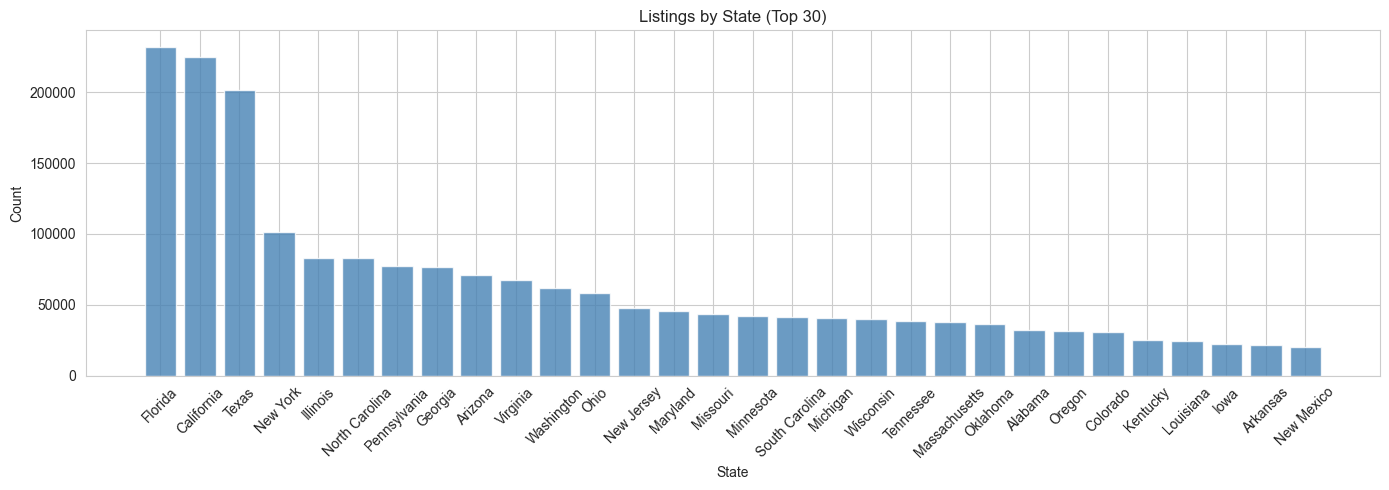

In [11]:
# State distribution
if 'state' in df.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    state_counts = df['state'].value_counts().head(30)
    ax.bar(state_counts.index, state_counts.values, color='steelblue', alpha=0.8)
    ax.set_title('Listings by State (Top 30)')
    ax.set_xlabel('State')
    ax.set_ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    # FIX: '../reports/plots/...' → 'reports/plots/...'
    plt.savefig('reports/plots/listings_by_state.png', dpi=150)
    plt.show()

## 12. Leakage Risk Report

In [12]:
leakage_report = generate_leakage_report(df, cfg)
print('Feature Leakage Risk Assessment:')
# FIX: '../data/processed/...' → 'data/processed/...'
leakage_report.to_csv('data/processed/leakage_report.csv', index=False)
print('✅ Saved to data/processed/leakage_report.csv')
leakage_report

2026-05-11 10:46:40,295 - src.ingestion - INFO - Leakage report generated — 12 columns assessed


Feature Leakage Risk Assessment:
✅ Saved to data/processed/leakage_report.csv


,column,dtype,nunique,null_pct,leakage_risk,action
0,status,object,3,0.00,LOW,Ordinal or OHE encoding
1,price,float64,102137,0.07,LOW,Keep — standard scaling
2,bed,float64,99,19.91,LOW,Keep — standard scaling
3,bath,float64,86,21.30,LOW,Keep — standard scaling
4,acre_lot,float64,16057,14.44,LOW,Keep — standard scaling
5,city,object,20098,0.06,MEDIUM,Frequency or target encoding (OOF-safe)
6,state,object,55,0.00,LOW,Ordinal or OHE encoding
7,zip_code,object,30334,0.01,MEDIUM,Frequency or target encoding (OOF-safe)
8,house_size,float64,12061,23.82,LOW,Keep — standard scaling
9,prev_sold_date,object,14916,31.71,MEDIUM,Extract year/month features only


## 13. Data Summary (Full)

In [13]:
summary = log_data_summary(df, cfg)

print(f"Total rows: {summary['total_rows']:,}")
print(f"Numerical columns: {summary['numerical_cols']}")
print(f"Categorical columns: {summary['categorical_cols']}")
print(f"High-cardinality columns: {summary['high_cardinality_cols']}")
print(f"\nColumns needing log transform: {summary['needs_log_transform']}")

print('\nNumerical Stats:')
pd.DataFrame(summary['numerical_describe'])

2026-05-11 10:46:42,622 - src.ingestion - INFO - ============================================================
2026-05-11 10:46:42,623 - src.ingestion - INFO - DATA SUMMARY — real_estate_fraud_detection
2026-05-11 10:46:42,625 - src.ingestion - INFO - ============================================================
2026-05-11 10:46:42,626 - src.ingestion - INFO -   Shape          : 2,147,656 rows × 10 columns
2026-05-11 10:46:42,627 - src.ingestion - INFO -   Numerical cols : ['price', 'bed', 'bath', 'acre_lot', 'house_size']
2026-05-11 10:46:42,631 - src.ingestion - INFO -   Categorical    : ['status', 'state']
2026-05-11 10:46:42,633 - src.ingestion - INFO -   High cardinality: ['city', 'zip_code']
2026-05-11 10:46:43,006 - src.ingestion - INFO -   Cardinality    : {'city': 20098, 'zip_code': 30334}
2026-05-11 10:46:43,008 - src.ingestion - INFO -   High-skew cols (|skew| > 1.0): {'price': 540.672, 'bed': 57.001, 'bath': 152.755, 'acre_lot': 104.674, 'house_size': 1278.421}
2026-05-11 10:

Total rows: 2,147,656
Numerical columns: ['price', 'bed', 'bath', 'acre_lot', 'house_size']
Categorical columns: ['status', 'state']
High-cardinality columns: ['city', 'zip_code']

Columns needing log transform: ['price', 'bed', 'bath', 'acre_lot', 'house_size']

Numerical Stats:


,price,bed,bath,acre_lot,house_size
count,2146203.00,1720154.00,1690293.00,1837444.00,1636117.00
mean,534900.58,3.28,2.50,15.49,2725.94
std,2172052.70,1.57,1.66,775.31,813524.52
min,0.00,1.00,1.00,0.00,4.00
25%,175000.00,3.00,2.00,0.15,1300.00
50%,330000.00,3.00,2.00,0.26,1762.00
75%,559900.00,4.00,3.00,0.97,2419.00
max,2147483600.00,473.00,830.00,100000.00,1040400400.00


## 14. Save Parquet + Day 1 Exit Criteria

In [14]:
# Save clean ingested data
from pathlib import Path
# FIX: f"../{cfg['data']['processed_path']}" → cfg['data']['processed_path']
# cfg mein already 'data/processed/' hai, '../' lagane se ek level upar jaata tha
processed_path = Path(cfg['data']['processed_path'])
processed_path.mkdir(parents=True, exist_ok=True)
out_path = processed_path / 'ingested.parquet'
df.to_parquet(out_path, index=False)
print(f'✅ Saved to {out_path} — shape: {df.shape}')

print('\n=== DAY 1 EXIT CRITERIA ===')
print(f'☑ Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} cols')
print(f'☑ Schema validation: PASSED')
print(f'☑ Price skewness: {price_info["skewness"]:.3f} → log transform: {price_info["log_transform_recommended"]}')
print(f'☑ Leakage report: saved to data/processed/leakage_report.csv')
print(f'☑ Plots saved to reports/plots/')
print(f'\n→ Fill in reports/eda_findings.md with key numbers before Day 2')

✅ Saved to data\processed\ingested.parquet — shape: (2147656, 10)

=== DAY 1 EXIT CRITERIA ===
☑ Dataset loaded: 2,147,656 rows, 10 cols
☑ Schema validation: PASSED
☑ Price skewness: 540.672 → log transform: True
☑ Leakage report: saved to data/processed/leakage_report.csv
☑ Plots saved to reports/plots/

→ Fill in reports/eda_findings.md with key numbers before Day 2
